In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Orbitals

### Non-tilted Sphere
Let $C$ be the $45^\circ\,\mathrm{N}$ line of latitude on a sphere $\mathcal{S}$ of radius $R$.  Our sphere and the plane $\mathcal{P}$ that $C$ rests on are given by:  

$$ \mathcal{S}:\; x^2 + y^2 + z^2 = R^2 \quad\quad\text{and}\quad\quad \mathcal{P}:\; z = R\sin 45^\circ$$

Of course $C$ is equal to the intersection of our sphere and plane.  Therefore $C$ is given by:  

$$ C:\; x^2+y^2 + R^2\sin^2 45^\circ = R^2 \quad\text{and}\quad z = R\sin 45^\circ$$

$$ x^2 + y^2 = R^2\cos^2 45^\circ = 0.5R^2 \quad\quad\text{and}\quad\quad z = R\sin 45^\circ$$

The position vector $\overrightarrow{\rho} = \rho\hat{\rho}$ that tracks $C$ is given by:  

$$ \overrightarrow{\rho} = \mathbf{r} + \frac{R}{\sqrt{2}}\,\mathbf{\hat{k}} \quad\quad\text{where }\, \mathbf{r} = r\,\mathbf{\hat{r}} = \frac{R}{\sqrt{2}}\,\langle \cos \theta,\sin\theta\rangle$$

$$ \rho\hat{\rho} = r\,\langle \cos\theta,\sin\theta,1\rangle$$

Just as $\mathbf{\hat{r}}$ varies with $\theta$, the unit vector, $\hat{\rho}$, varies with $\theta$ and $\phi$.  To find out how, let's find the relationship between the $x,y,z$ rectilinear coordinates of a point to it's $\rho,\theta,\phi$ spherical coordinates.  

$$ x = r\cos\theta\quad\quad y = r\sin\theta \quad\quad z = \rho\cos\phi$$

$$ r = \rho\sin\phi \quad\quad x = \rho\sin\phi\cos\theta \quad\quad y = \rho\sin\phi\sin\theta$$

Now we have,  

$$ \overrightarrow{\rho} = x\,\mathbf{\hat{i}} + y\,\mathbf{\hat{j}} + z\,\mathbf{\hat{k}} = \rho\big( \sin\phi\cos\theta\,\mathbf{\hat{i}} + \sin\phi\sin\theta\,\mathbf{\hat{j}} + \cos\phi\,\mathbf{\hat{k}}\big) = \rho\hat{\rho}  $$

Therefore,  

$$ \hat{\rho} := \hat{\rho}(\theta,\phi) = \sin\phi\cos\theta\,\mathbf{\hat{i}} + \sin\phi\sin\theta\,\mathbf{\hat{j}} + \cos\phi\,\mathbf{\hat{k}}$$

Now, let $\alpha$ be the angle between $\hat{\rho}$ and $\mathbf{i}$ and $\beta$ be the angle between $\hat{\rho}$ and $\mathbf{j}$.  

$$ \overrightarrow{\rho} = \mathbf{i} + \mathbf{j} + \mathbf{k} = x\,\mathbf{\hat{i}} + y\,\mathbf{\hat{j}} + z\,\mathbf{\hat{k}}$$

$$ x = \big(\overrightarrow{\rho}\cdot \mathbf{\hat{i}}\big) \quad\quad y = \big(\overrightarrow{\rho}\cdot \mathbf{\hat{j}}\big) \quad\quad z = \big(\overrightarrow{\rho}\cdot \mathbf{\hat{k}}\big)$$

$$ x = \rho\cos\alpha \quad\quad y = \rho\cos\beta \quad\quad z = \rho\cos\phi$$

Therefore,  

$$ \overrightarrow{\rho} = \rho\langle \cos\alpha,\cos\beta,\cos\phi\rangle$$

Which means that:  

$$ \sin\phi\cos\theta = \cos\alpha \quad\quad\text{and}\quad\quad \sin\phi\sin\theta = \cos\beta$$

Now let:  

$$ \theta:=\theta(t) = \omega t + \theta_0$$

$$ \mathbf{v} := \frac{\mathrm{d}\overrightarrow{\rho}}{\mathrm{d}t} = \frac{\partial \overrightarrow{\rho}}{\partial t} = \omega\frac{\mathrm{d}\overrightarrow{\rho}}{\mathrm{d}\theta}$$

$$ \overrightarrow{\rho}\;'(\theta) = \mathbf{r}'(\theta) = r\,\hat{\theta}$$

Therefore,  

$$ \mathbf{v} = \mathbf{v}(t) = \omega r \hat{\theta}$$

Furthermore,  

$$ \mathbf{a} = \mathbf{v}'(t)= \omega \,\frac{\mathrm{d}\mathbf{v}}{\mathrm{d}\theta} = -\omega^2 r \,\mathbf{\hat{r}} $$

Assuming $\mathcal{S}$ is an abstraction of the the surface of the Earth,  

$$ R \approxeq 6378.137 \mathrm{km} \quad\quad\text{and}\quad\quad \omega = \frac{1}{1\,\mathrm{day}}$$

In seconds, the angular velocity is given by:  

$$ \omega = \frac{1}{1\,\mathrm{day}}\,\frac{1\,\mathrm{day}}{24\mathrm{h}}\,\frac{1\mathrm{h}}{60\mathrm{m}}\,\frac{1\mathrm{m}}{60\mathrm{s}} = \frac{1}{8.64\mathrm{e}4\mathrm{s}}$$

In [5]:
omega = 1/(24*60**2)
R = 6378137; r = R/np.sqrt(2); r

np.float64(4510023.924036822)

The magnitude of the acceleration of a point moving through $C$ is equal to the radial acceleration thereof.  

$$ a = |\mathbf{a}| = \omega^2 r \approxeq 6.042\cdot10^{-4}\,\frac{\mathrm{m}}{\mathrm{s}^2}$$

In [6]:
a = r*omega**2; a

np.float64(0.0006041591547760232)

/tmp/ipykernel_9359/2081816606.py:10: RuntimeWarning: invalid value encountered in sqrt
  f = np.sqrt(R**2 - x**2 - y**2)


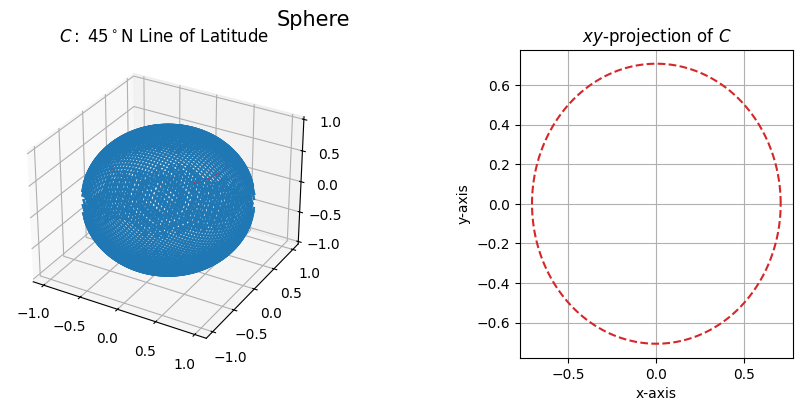

In [4]:
R = 1
r_mag = R/np.sqrt(2)

theta = np.linspace(0,2*np.pi,num=200)
r_dir = np.array([np.cos(theta),np.sin(theta)])
r = r_mag*r_dir

x = np.linspace(-1,1,num=50)
x, y = np.meshgrid(x,x)
f = np.sqrt(R**2 - x**2 - y**2)

rho = r.copy()
rho.resize((3,200))
rho[2].fill(r_mag)

fig = plt.figure(figsize=(12,4))
fig.suptitle('Sphere',size=15)

ax1 = fig.add_subplot(1,3,(1,2), projection='3d')
ax1.set_title(r'$C:\; 45^\circ\mathrm{N}$ Line of Latitude')
ax1.plot_wireframe(x,y,f, color='tab:blue')
ax1.plot_wireframe(x,y,-f, color='tab:blue')
ax1.plot(*rho, ls='--', color='tab:red')

ax2 = fig.add_subplot(1,3,3)
ax2.set_title(r'$xy$-projection of $C$')
ax2.set_xlabel('x-axis')
ax2.set_ylabel('y-axis')
ax2.grid()

ax2.plot(*r, ls='--', color='tab:red')

### Tilted Sphere

Now, let $\mathcal{S}'$ be equal to $\mathcal{S}$ rotated around $\mathbf{\hat{j}}$ by $45^\circ$.  Moreover, let $\mathcal{S}'$ be equipped with it's own coordinate system with $\mathbf{\hat{i}}', \mathbf{\hat{j}}', \mathbf{\hat{k}}'$ as it's orthonormal basis.  Of course this orthonormal basis is equal to the one that $\mathcal{S}$ is equipped with -- that is, $\mathbf{\hat{i}}, \mathbf{\hat{j}}, \mathbf{\hat{k}}$ -- rotated around $\mathbf{\hat{j}}$ or the $y$-axis by $45^\circ$.  Which means that:  

$$ \mathbf{\hat{i}}' = \langle \cos 45^\circ, 0, \sin 45^\circ \rangle = \frac{1}{\sqrt{2}}\,\big(\mathbf{\hat{i}} + \mathbf{\hat{k}} \big)$$

$$ \mathbf{\hat{k}}' = \langle -\sin 45^\circ , 0, \cos 45^\circ\rangle = \frac{1}{\sqrt{2}}\,\big(-\mathbf{\hat{i}} + \mathbf{\hat{k}}\big)$$

And, of course, $\mathbf{\hat{j}}' = \mathbf{\hat{j}}$.  The $45^\circ\mathrm{N}$ line of latitude of $\mathcal{S}'$, denoted as $C'$, is equal to the intersection of the plane $\mathcal{P}'$ and $\mathcal{S}'$.  To find the equation that gives $\mathcal{P}'$, first note that $\mathbf{\hat{k}}$ is normal to it.  Thus,  

$$ \mathcal{P}':\; z - x = \sqrt{2}A$$

where $A \in\mathbb{R}$ is to be found by passing the cooordinates of some point in $\mathcal{P}'$ to the above equation.  Via the fact that $\mathcal{P}'$ is equal to $\mathcal{P}$ rotated around $\mathbf{\hat{j}}$ by $45^\circ$ in conjunction with the fact that the head of $\mathbf{k}$ is in $\mathcal{P}$, the head of $\mathbf{k}'$ is in $\mathcal{P}'$.  Now, what are the coordinates of the head this vector.  

$$ \mathbf{k}' = z'\,\mathbf{\hat{k}}' = z\,\mathbf{\hat{k}}' = \frac{R}{2}\,\big(-\mathbf{\hat{i}} + \mathbf{\hat{k}}\big)$$

Passing the compliments of the above vector to the equation that gives $\mathcal{P}'$ gives:  

$$ R = \sqrt{2}A \quad\therefore\quad A = \frac{R}{\sqrt{2}}$$

Thus,  

$$ \mathcal{P}':\; z-x = R$$

Note that $\mathcal{S}'$ is given by the same equation that gives $\mathcal{S}$, which is:  

$$ \mathcal{S}':\; x^2 + y^2 + z^2 = R^2$$

Via the above two equations:  

$$ x^2 + y^2 + (R+x)^2 = R^2 $$

$$ x^2 + y^2 + x^2 + 2Rx + R^2 = R^2 $$

Thus, one of the equations that the $45^\circ \mathrm{N}$ line of latitude of $\mathcal{S}'$ is given by:  

$$C':\; 2x^2 +y^2 + 2Rx = 0$$

As for another,  

$$ (z - R)^2 + y^2 + z^2 = R^2$$

$$ 2z^2 +y^2 - 2Rz = 0$$

Thus, $C'$ is given by:  

$$ 2x^2 + y^2 + 2Rx = 0 \quad\quad\text{and}\quad\quad 2z^2 + y^2 - 2Rz = 0$$

As for $\overrightarrow{\rho}\;'$, the position vector that tracks $C'$, first note that:  

$$ \mathbf{k}'\cdot \mathbf{r}'  = z'r'\cos 90^\circ = 0$$

Therefore,  

$$ \frac{R}{\sqrt{2}}\big(r_3' -r_1' \big)= 0$$

$$ r_1' = r_3'$$

And,  

$$ \mathbf{i}' = \frac{R}{2}\big(\mathbf{\hat{i}} + \mathbf{\hat{k}}\big)$$

$$ \mathbf{i}'\cdot\mathbf{r}' = x'r'\cos\theta' = \frac{R^2}{2}\cos\theta'$$

$$r_1 + r_3= R\cos\theta'$$

$$ r_1 = r_3 = \frac{R}{2}\cos\theta'$$

So, for $\mathbf{r}'$, we have:  

$$ \mathbf{r}' = \frac{R}{2}\cos\theta'\,\mathbf{\hat{i}} + r_2\,\mathbf{\hat{j}} + \frac{R}{2}\cos\theta'\,\mathbf{\hat{k}}$$

As for $r_2$,  

$$ r_1^2 + r_2^2 + r_3^2 = r'^2 = \frac{R^2}{2}$$

$$ r_2^2 = \frac{R^2}{2} - \frac{R^2}{2}\cos^2\theta'$$

$$ \pm r_2 = \frac{R}{\sqrt{2}}\sin\theta'$$

Finally, for $\mathbf{r}'$ we have:  

$$ \mathbf{r}' := \mathbf{r}'(\theta') = \frac{R}{\sqrt{2}}\left(\frac{\cos\theta'}{\sqrt{2}}\,\mathbf{\hat{i}} + \sin\theta'\,\mathbf{\hat{j}} + \frac{\cos\theta'}{\sqrt{2}}\,\mathbf{\hat{k}}\right)$$

$$ = r\,\mathbf{\hat{r}}'\quad\quad\text{where }\, \mathbf{\hat{r}}' = \frac{\cos\theta'}{\sqrt{2}}\,\mathbf{\hat{i}} + \sin\theta'\,\mathbf{\hat{j}} + \frac{\cos\theta'}{\sqrt{2}}\,\mathbf{\hat{k}}$$

Now, on to $\overrightarrow{\rho}\;'$.  Since $C$ is congruent with $C'$,  

$$  \overrightarrow{\rho} = \mathbf{r} + \frac{R}{\sqrt{2}}\,\mathbf{\hat{k}}\quad\quad\hat{=}\quad\quad \overrightarrow{\rho}\;' =  \mathbf{r}' + r\,\mathbf{\hat{k}}'$$

$$ \overrightarrow{\rho}\;' = r\big(\mathbf{\hat{r}}' + \mathbf{\hat{k}}'\big)$$

Recall that:  

$$ \mathbf{\hat{k}}' =  \frac{1}{\sqrt{2}}\,\big(-\mathbf{\hat{i}} + \mathbf{\hat{k}}\big) $$

Thus, our position vector $\overrightarrow{\rho}\;'$ is given by:  

$$ \overrightarrow{\rho}\;' = r\left(\frac{1}{\sqrt{2}}\big(\cos\theta' - 1\big)\,\mathbf{\hat{i}} + \sin\theta'\,\mathbf{\hat{j}} + \frac{1}{\sqrt{2}}\big(\cos\theta' + 1\big)\,\mathbf{\hat{k}}\right)$$

In [14]:
r_mag

np.float64(0.7071067811865475)

Now, let's verify the above by plugging the rectilinear $x,y,z$ compliments into the equations that give $C'$.  As for the first equation:  

$$ C':\;2x^2 + y^2 + 2Rx = 0$$

$$ r^2(\cos\theta'-1)^2 + r^2\sin^2\theta' + 2R\,\frac{r}{\sqrt{2}}(\cos\theta'-1) = 0$$

$$ r\big(\cos^2\theta' - 2\cos\theta' + 1\big) + r\sin^2\theta' + \sqrt{2}R(\cos\theta'-1)=0$$

$$ r - 2r\cos\theta' + r + \sqrt{2}R\cos\theta' - \sqrt{2}R = 0$$

$$ 2r - \sqrt{2}R = 0 \quad\therefore\quad\sqrt{2}R - \sqrt{2}R = 0$$

So, we have verified the aforementioned identity of $\overrightarrow{\rho}\;'$ against the equation that gives the projection of $C'$ onto the $x,y$-plane.  Now, let's verify agains the equation that gives the projection of $C'$ onto the $y,z$-plane.  

$$ C':\; 2z^2 + y^2 - 2Rz = 0$$

$$ r^2(\cos\theta'+1)^2 + r^2\sin^2\theta' - \sqrt{2}Rr(\cos\theta' + 1) = 0$$

$$ r\big(\cos^2\theta' + 2\cos\theta' + 1\big) + r\sin^2\theta' - \sqrt{2}R(\cos\theta'+1) = 0$$

$$ 2r + 2r\cos\theta' = \sqrt{2}R\cos\theta' +\sqrt{2}R$$

$$ \sqrt{2}R + \sqrt{2}R\cos\theta'= \sqrt{2}R\cos\theta' + \sqrt{2}R$$

And, another verification.

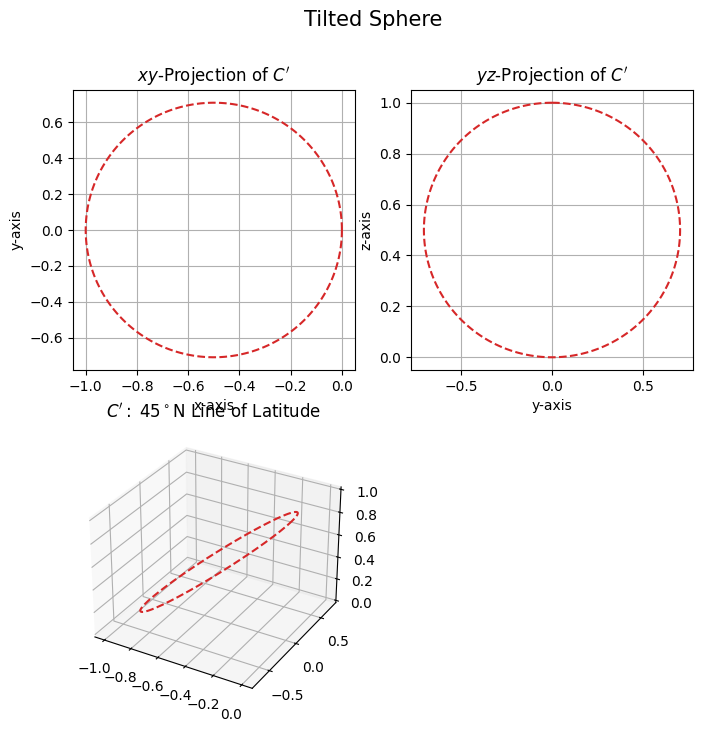

In [15]:
rho_x = r_mag*(np.cos(theta)-1)/np.sqrt(2)
rho_y = r_mag*np.sin(theta)
rho_z = r_mag*(np.cos(theta)+1)/np.sqrt(2)
p = rho = np.array([rho_x,rho_y,rho_z])

fig = plt.figure(figsize=(8,8))
fig.suptitle('Tilted Sphere', size=15)

ax1 = fig.add_subplot(2,2,1)
ax1.set_title(r"$xy$-Projection of $C'$")
ax1.set_xlabel('x-axis')
ax1.set_ylabel('y-axis')
ax1.grid()

ax1.plot(p[0],p[1], ls = '--', color = 'tab:red')

ax2 = fig.add_subplot(2,2,2)
ax2.set_title(r"$yz$-Projection of $C'$")
ax2.set_xlabel('y-axis')
ax2.set_ylabel('z-axis')
ax2.grid()

ax2.plot(p[1], p[2], ls='--', color = 'tab:red')

ax3 = fig.add_subplot(2,2,3, projection='3d')
ax3.set_title(r"$C':\;45^\circ\mathrm{N}$ Line of Latitude")

ax3.plot(*p, ls='--', color='tab:red')